# 04 Neurosymbolic Inference Heatmap

Interactive notebook for neurosymbolic inference with heatmap explanations from uploaded PCB images.

- Faster R-CNN provides backbone, RPN, RoI Align, bbox regressor, and detection post-processing.
- SODT replaces the classification branch and receives the flattened RoI Align pooled grid `[C, 7, 7]`.
- Explanations display **Local Evidence per decision node**, not a combined path heatmap.


In [1]:
from pathlib import Path
import io

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output, display
from PIL import Image
from torch.utils.data import DataLoader

from notebooks.util import resolve_root
from neuro.config import NeuroConfig, NeuroTrainConfig
from neuro.prepare_dataset import PCBDataset
from neuro.preprocess_dataset import test_preprocess
from neuro.train import evaluate_model
from neuro.utils import detection_collate_fn
from neurosym.inference import (
    explain_hybrid_detection,
    load_neurosymbolic_detector,
    run_neurosymbolic_inference,
    select_detection_indices,
)
from neurosym.visualization import (
    draw_neurosymbolic_explanation,
    draw_numbered_detections,
)
from util.config import load_yaml
from util.device import select_device

PROJECT_ROOT = resolve_root()

In [2]:
neuro_config = load_yaml(Path("neuro.yaml"), NeuroConfig)
train_config = load_yaml(Path("neuro_train.yaml"), NeuroTrainConfig)

device = select_device(train_config["device"])
detector_checkpoint_path = PROJECT_ROOT / "checkpoints" / "neuro" / "BESTEST.pt"
symbolic_checkpoint_path = PROJECT_ROOT / "checkpoints" / "symbolic" / "run4.pt"

hybrid_model, detector_checkpoint = load_neurosymbolic_detector(
    detector_checkpoint_path=detector_checkpoint_path,
    neuro_config=neuro_config,
    train_config=train_config,
    symbolic_checkpoint_path=symbolic_checkpoint_path,
    device=str(device),
)

image_preprocess = test_preprocess()
class_names = tuple(train_config["dataset"]["class_names"])

detector_checkpoint_path, symbolic_checkpoint_path

(PosixPath('/home/wiszel/OneDrive/Documents/WiszeL/UNS/Semester 8/pcb_skripsi/checkpoints/neuro/BESTEST.pt'),
 PosixPath('/home/wiszel/OneDrive/Documents/WiszeL/UNS/Semester 8/pcb_skripsi/checkpoints/symbolic/run4.pt'))

## Batch Evaluation

Test samples: 500


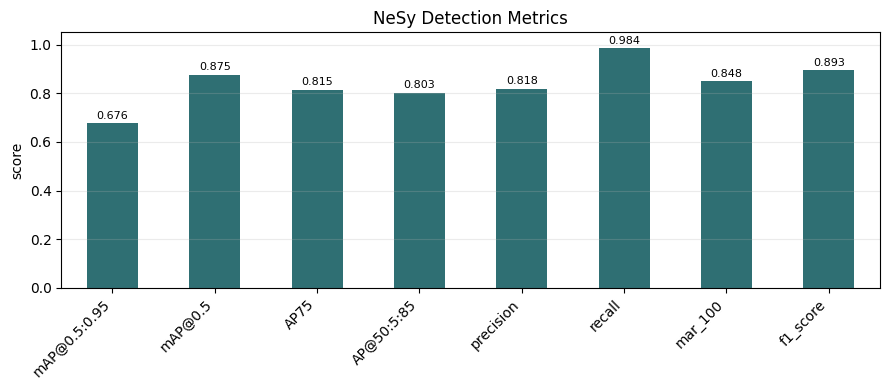

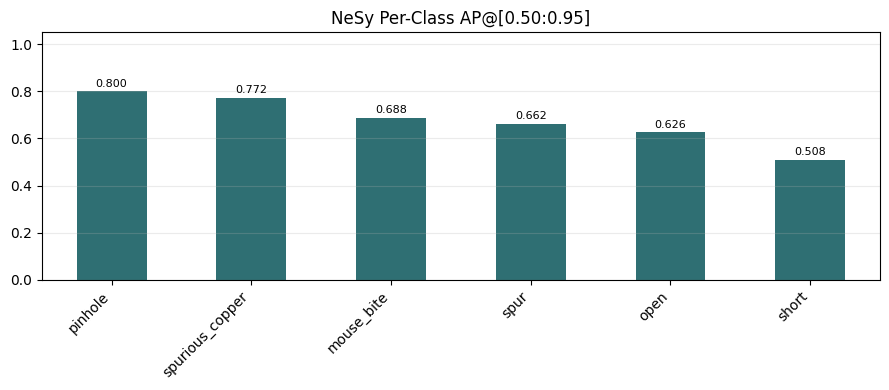

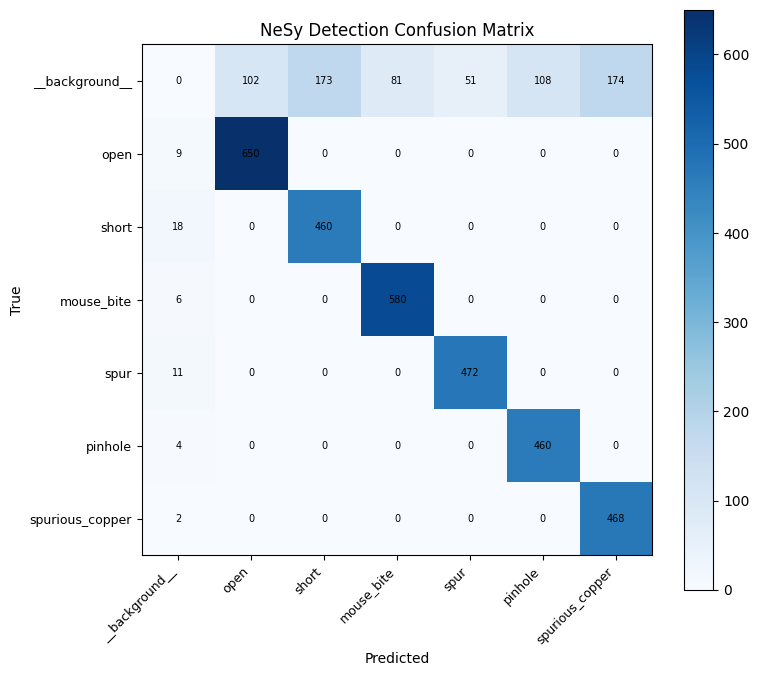

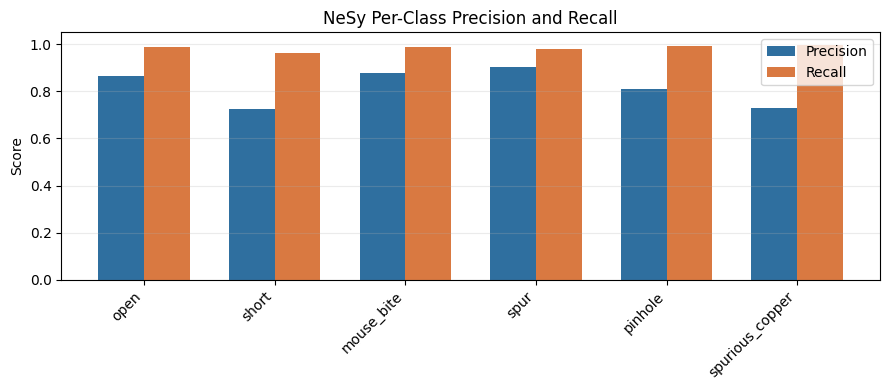

Inference time: 391.67 ms
Parameters: 36,228,914


,mAP@0.5:0.95,mAP@0.5,AP75,AP@50:5:85,precision,recall,mar_100,f1_score
0,0.675837,0.874685,0.815063,0.802763,0.817677,0.984076,0.848158,0.893193


In [3]:
test_dataset = PCBDataset(train_config, "test.txt")
test_dataset.add_preprocess(test_preprocess())
test_loader = DataLoader(
    test_dataset,
    batch_size=train_config["dataset"]["batch_size"],
    shuffle=False,
    collate_fn=detection_collate_fn,
)
print(f"Test samples: {len(test_dataset)}")

metrics = evaluate_model(
    model=hybrid_model,
    data_loader=test_loader,
    device=device,
    train_config=train_config,
)

skip_keys = {"precision_recall_score_threshold", "inference_time_ms", "parameter_count"}
metric_frame = pd.DataFrame(
    [
        {
            key: value
            for key, value in metrics.items()
            if isinstance(value, (int, float)) and key not in skip_keys
        }
    ]
)
ax = metric_frame.T.plot(kind="bar", legend=False, figsize=(9, 4), color="#2f6f73")
ax.set_title("NeSy Detection Metrics")
ax.set_ylabel("score")
ax.set_ylim(0.0, 1.05)
ax.grid(axis="y", alpha=0.25)
ax.bar_label(ax.containers[0], fmt="%.3f", padding=2, fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

if "per_class_AP" in metrics:
    s = pd.Series(metrics["per_class_AP"], name="AP").sort_values(ascending=False)
    ax = s.plot(kind="bar", figsize=(9, 4), color="#2f6f73")
    ax.set_title("NeSy Per-Class AP@[0.50:0.95]")
    ax.set_ylim(0.0, 1.05)
    ax.grid(axis="y", alpha=0.25)
    ax.bar_label(ax.containers[0], fmt="%.3f", padding=2, fontsize=8)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

if "confusion_matrix" in metrics:
    cm = np.array(metrics["confusion_matrix"])
    labels = metrics["confusion_matrix_labels"]
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("NeSy Detection Confusion Matrix")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=7)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

if "per_class_precision" in metrics:
    pr = [k for k in metrics["per_class_precision"] if k != "__background__"]
    x = np.arange(len(pr))
    w = 0.35
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(
        x - w / 2,
        [metrics["per_class_precision"][c] for c in pr],
        w,
        label="Precision",
        color="#2F6F9F",
    )
    ax.bar(
        x + w / 2,
        [metrics["per_class_recall"][c] for c in pr],
        w,
        label="Recall",
        color="#D97941",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(pr, rotation=45, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title("NeSy Per-Class Precision and Recall")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()
    print(f"Inference time: {metrics.get('inference_time_ms', 0):.2f} ms")
    print(f"Parameters: {metrics.get('parameter_count', 0):,}")

metric_frame

In [4]:
def class_name(label: int) -> str:
    return class_names[int(label) - 1]

In [ ]:
upload_widget = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Upload Image",
)
MAX_DISPLAY_DETECTIONS = 9
DISPLAY_SCORE_THRESHOLD = 0.3
detection_output = widgets.Output()
explanation_output = widgets.Output()
state = {
    "image_name": None,
    "image_tensor": None,
    "detection": None,
    "selected_indices": [],
}


def uploaded_file_record():
    value = upload_widget.value
    if isinstance(value, tuple):
        return value[0] if value else None
    if isinstance(value, dict):
        if "content" in value:
            return value
        return next(iter(value.values())) if value else None
    return None


def uploaded_content_bytes(file_record) -> bytes:
    content = file_record["content"]
    return content.tobytes() if isinstance(content, memoryview) else bytes(content)


def render_detection(detection_index: int) -> None:
    image_tensor = state["image_tensor"]
    detection = state["detection"]
    selected_indices = state["selected_indices"]
    explanation = explain_hybrid_detection(
        hybrid_model,
        detection,
        detection_index=detection_index,
        image_shape=tuple(image_tensor.shape[-2:]),
    )
    with explanation_output:
        clear_output(wait=True)
        selected_number = selected_indices.index(detection_index) + 1
        draw_neurosymbolic_explanation(
            image_tensor,
            detection,
            detection_index,
            explanation,
            class_names,
            hybrid_model.symbolic_tree,
            selected_number=selected_number,
        )


def make_detection_button(display_number: int, detection_index: int) -> widgets.Button:
    detection = state["detection"]
    label = int(detection["labels"][detection_index])
    score = float(detection["scores"][detection_index])
    button = widgets.Button(
        description=f"#{display_number} {class_name(label)} {score:.2f}",
        layout=widgets.Layout(width="180px"),
    )
    button.on_click(lambda _: render_detection(detection_index))
    return button


def run_uploaded_inference(_button) -> None:
    file_record = uploaded_file_record()
    with detection_output:
        clear_output(wait=True)
        explanation_output.clear_output(wait=True)

        if file_record is None:
            print("Upload one PCB image first.")
            return

        image_name = file_record.get("name", "uploaded_image")
        pil_image = Image.open(io.BytesIO(uploaded_content_bytes(file_record))).convert(
            "RGB"
        )
        image_tensor = image_preprocess(pil_image)
        detection = run_neurosymbolic_inference(hybrid_model, [image_tensor])[0]
        selected_indices = select_detection_indices(
            detection,
            score_threshold=DISPLAY_SCORE_THRESHOLD,
            max_detections=MAX_DISPLAY_DETECTIONS,
        )

        state["image_name"] = image_name
        state["image_tensor"] = image_tensor
        state["detection"] = detection
        state["selected_indices"] = selected_indices

        fig, axis = plt.subplots(figsize=(8, 8))
        draw_numbered_detections(
            axis, image_tensor, detection, selected_indices, class_names
        )
        axis.set_title(f"Neuro-Symbolic detections: {image_name}")
        plt.show()

        if not selected_indices:
            print("No detections were returned by the model.")
            return

        buttons = [
            make_detection_button(display_number, detection_index)
            for display_number, detection_index in enumerate(selected_indices, start=1)
        ]
        display(
            widgets.GridBox(
                buttons,
                layout=widgets.Layout(
                    grid_template_columns="repeat(3, 190px)",
                    grid_gap="8px",
                ),
            )
        )

        render_detection(selected_indices[0])


def run_uploaded_inference_on_upload(change) -> None:
    if change["new"]:
        run_uploaded_inference(None)


upload_widget.observe(run_uploaded_inference_on_upload, names="value")
display(
    widgets.VBox(
        [
            upload_widget,
            detection_output,
            explanation_output,
        ]
    )
)